Project 1: Employee Attrition Risk & Segmentation

Primary task: Classification
Dataset: IBM HR Analytics Employee Attrition & Performance (Kaggle)

Problem Statement: Predict whether an employee is likely to leave, and segment employees into behavioral personas so the prediction is actionable for HR rather than just a probability.

Deliverables:

EDA + preprocessing (encoding, scaling, train/test split)
Classification models — Logistic Regression, Random Forest, XGBoost — tuned (Grid/Random Search), tracked in MLflow, evaluated on precision/recall/F1 (justify the priority metric for attrition)
Clustering on tenure, satisfaction, income, overtime, work-life balance — K-Means + 2 others, compared on silhouette score, into named personas (e.g. "flight-risk newcomers," "stable veterans")
FastAPI: POST /predict (attrition risk) and GET /segment (persona)
Docker + Streamlit: input an employee profile → risk score + persona + a suggested retention action per persona


In [108]:
import warnings
warnings.filterwarnings("ignore")

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import zscore

import mlflow
import mlflow.sklearn

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import PowerTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

import mlflow
import mlflow.sklearn

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)



from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report
)

pd.set_option("display.width", 130)

df=pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df.head()

#http://127.0.0.1:5000


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [109]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [110]:
df.dtypes.value_counts()


int64     26
object     9
Name: count, dtype: int64

In [111]:
numeric_columns = df.select_dtypes(include="number").columns
categorical_columns = df.select_dtypes(include="object").columns

print("Numeric columns:")
print(numeric_columns.tolist())

print("\nCategorical columns:")
print(categorical_columns.tolist())

Numeric columns:
['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns:
['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


In [112]:
df["Attrition_encoded"] = df["Attrition"].map({
    "No": 0,
    "Yes": 1
})

In [113]:
df["EducationField"].value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

In [114]:
travel_mapping = {
    "Non-Travel": 0,
    "Travel_Rarely": 1,
    "Travel_Frequently": 2
}

df["BusinessTravel_encoded"] = df["BusinessTravel"].map(travel_mapping)

In [115]:
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [116]:
df = pd.get_dummies(
    df,
    columns=["Department"],
    prefix="Department",
    dtype=int
)

In [117]:
df = pd.get_dummies(
    df,
    columns=["EducationField"],
    prefix=["EducationField"],
    dtype=int
)

In [118]:
df["Gender_encoded"] = df["Gender"].map({
    "Female": 0,
    "Male": 1
})

In [121]:
df = pd.get_dummies(
    df,
    columns=["MaritalStatus"],
    prefix="MaritalStatus",
    dtype=int
)

KeyError: "None of [Index(['MaritalStatus'], dtype='object')] are in the [columns]"

In [122]:
df["OverTime_encoded"] = df["OverTime"].map({
    "No": 0,
    "Yes": 1
})

In [123]:
df = pd.get_dummies(
    df,
    columns=["JobRole"],
    prefix="JobRole",
    dtype=int
)

In [57]:
df["OverTime_encoded"] = df["OverTime"].map({
    "No": 0,
    "Yes": 1
})

In [124]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 56 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                1470 non-null   int64 
 1   Attrition                          1470 non-null   object
 2   BusinessTravel                     1470 non-null   object
 3   DailyRate                          1470 non-null   int64 
 4   DistanceFromHome                   1470 non-null   int64 
 5   Education                          1470 non-null   int64 
 6   EmployeeCount                      1470 non-null   int64 
 7   EmployeeNumber                     1470 non-null   int64 
 8   EnvironmentSatisfaction            1470 non-null   int64 
 9   Gender                             1470 non-null   object
 10  HourlyRate                         1470 non-null   int64 
 11  JobInvolvement                     1470 non-null   int64 
 12  JobLev

Make the feature groups

In [125]:
target_feature = "Attrition_encoded"

hr_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "Education",
    "EnvironmentSatisfaction",
    "HourlyRate",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager",

    # Ordinal/binary encoded
    "BusinessTravel_encoded",
    "Gender_encoded",
    "OverTime_encoded",

    # Marital status
    "MaritalStatus_Divorced",
    "MaritalStatus_Married",
    "MaritalStatus_Single",

    # Job roles
    "JobRole_Healthcare Representative",
    "JobRole_Human Resources",
    "JobRole_Laboratory Technician",
    "JobRole_Manager",
    "JobRole_Manufacturing Director",
    "JobRole_Research Director",
    "JobRole_Research Scientist",
    "JobRole_Sales Executive",
    "JobRole_Sales Representative",

    # Departments
    "Department_Human Resources",
    "Department_Research & Development",
    "Department_Sales",

    # Education fields
    "EducationField_Human Resources",
    "EducationField_Life Sciences",
    "EducationField_Marketing",
    "EducationField_Medical",
    "EducationField_Other",
    "EducationField_Technical Degree"
]

excluded_features = [
    "Attrition",
    "BusinessTravel",
    "Gender",
    "OverTime",
    "EmployeeNumber",
    "EmployeeCount",
    "Over18",
    "StandardHours"
]

X = df[hr_features]
y = df[target_feature]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [127]:
numerical_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "Education",
    "EnvironmentSatisfaction",
    "HourlyRate",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyIncome",
    "MonthlyRate",
    "NumCompaniesWorked",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TotalWorkingYears",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsAtCompany",
    "YearsInCurrentRole",
    "YearsSinceLastPromotion",
    "YearsWithCurrManager"
]

skewness = df[numerical_features].skew()

skewness

Age                         0.413286
DailyRate                  -0.003519
DistanceFromHome            0.958118
Education                  -0.289681
EnvironmentSatisfaction    -0.321654
HourlyRate                 -0.032311
JobInvolvement             -0.498419
JobLevel                    1.025401
JobSatisfaction            -0.329672
MonthlyIncome               1.369817
MonthlyRate                 0.018578
NumCompaniesWorked          1.026471
PercentSalaryHike           0.821128
PerformanceRating           1.921883
RelationshipSatisfaction   -0.302828
StockOptionLevel            0.968980
TotalWorkingYears           1.117172
TrainingTimesLastYear       0.553124
WorkLifeBalance            -0.552480
YearsAtCompany              1.764529
YearsInCurrentRole          0.917363
YearsSinceLastPromotion     1.984290
YearsWithCurrManager        0.833451
dtype: float64

In [128]:
skewed_features = [
    "MonthlyIncome",
    "NumCompaniesWorked",
    "TotalWorkingYears",
    "YearsAtCompany",
    "YearsSinceLastPromotion"
]

numerical_features = [
    "Age",
    "DailyRate",
    "DistanceFromHome",
    "Education",
    "EnvironmentSatisfaction",
    "HourlyRate",
    "JobInvolvement",
    "JobLevel",
    "JobSatisfaction",
    "MonthlyRate",
    "PercentSalaryHike",
    "PerformanceRating",
    "RelationshipSatisfaction",
    "StockOptionLevel",
    "TrainingTimesLastYear",
    "WorkLifeBalance",
    "YearsInCurrentRole",
    "YearsWithCurrManager"
]

ordinal_features = [
    "BusinessTravel_encoded"
]

encoded_categorical_features = [
 
    # Binary encoded
    "Gender_encoded",
    "OverTime_encoded",

    # Marital status
    "MaritalStatus_Divorced",
    "MaritalStatus_Married",
    "MaritalStatus_Single",

    # Job roles
    "JobRole_Healthcare Representative",
    "JobRole_Human Resources",
    "JobRole_Laboratory Technician",
    "JobRole_Manager",
    "JobRole_Manufacturing Director",
    "JobRole_Research Director",
    "JobRole_Research Scientist",
    "JobRole_Sales Executive",
    "JobRole_Sales Representative",

    # Departments
    "Department_Human Resources",
    "Department_Research & Development",
    "Department_Sales",

    # Education fields
    "EducationField_Human Resources",
    "EducationField_Life Sciences",
    "EducationField_Marketing",
    "EducationField_Medical",
    "EducationField_Other",
    "EducationField_Technical Degree"
]

In [129]:
# Creating preprocessing pipelines for features

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

skewed_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "log_transform",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        ("scaler", StandardScaler())
    ]
)

ordinal_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

In [130]:


preprocessor = ColumnTransformer(
    transformers=[
        ("skewed", skewed_pipeline, skewed_features),
        ("numeric", numeric_pipeline, numerical_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        (
            "categorical",
            categorical_pipeline,
            encoded_categorical_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [131]:
#Start MLflow 
#mlflow.set_tracking_uri("sqlite:///mlflow_attrition.db")
#mlflow.set_experiment("attrition")


import os
import mlflow

# Store MLflow experiment data in a SQLite database
mlflow.set_tracking_uri("sqlite:///mlflow_attrition.db")

# Create or select the experiment
experiment = mlflow.set_experiment("attrition")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Database location:", os.path.abspath("mlflow_attrition.db"))


MLflow version: 3.14.0
Tracking URI: sqlite:///mlflow_attrition.db
Experiment name: attrition
Experiment ID: 1
Database location: c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction\mlflow_attrition.db


In [132]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [133]:
import os
import mlflow
import mlflow.sklearn

mlflow.set_tracking_uri("sqlite:///mlflow_attrition.db")
experiment = mlflow.set_experiment("attrition")

print("MLflow version:", mlflow.__version__)
print("Tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", experiment.name)
print("Experiment ID:", experiment.experiment_id)
print("Database location:", os.path.abspath("mlflow_attrition.db"))

MLflow version: 3.14.0
Tracking URI: sqlite:///mlflow_attrition.db
Experiment name: attrition
Experiment ID: 1
Database location: c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction\mlflow_attrition.db


In [134]:
with mlflow.start_run(run_name="logistic_regression"):
    model_pipeline.fit(X_train, y_train)

    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )
    roc_auc = roc_auc_score(y_test, y_prob)

    mlflow.log_params({
        "model": "LogisticRegression",
        "class_weight": "balanced",
        "max_iter": 1000,
        "test_size": 0.20,
        "random_state": 42
    })

    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        name="attrition_model",
        input_example=X_train.head(5),
        skops_trusted_types=["numpy.dtype"]
    )

print("Model training and MLflow logging completed.")

2026/07/26 06:09:49 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:09:50 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:09:50 INFO mlflow.utils.environment: Detected uv project at c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction. Attempting to export requirements via 'uv export'.
2026/07/26 06:09:55 INFO mlflow.utils.uv_utils: Exported 176 dependencies via uv
2026/07/26 06:09:55 INFO mlflow.utils.environment: Successfully exported 176 requirements from uv project. Skipping package capture based inference.
2026/07/26 06:09:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a versio

Model training and MLflow logging completed.


Random forset classifier

In [135]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [136]:
with mlflow.start_run(run_name="random_forest"):
    random_forest_pipeline.fit(X_train, y_train)

    y_pred = random_forest_pipeline.predict(X_test)
    y_prob = random_forest_pipeline.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    mlflow.log_params({
        "model": "RandomForestClassifier",
        "n_estimators": 200,
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1,
        "test_size": 0.20
    })

    mlflow.log_metrics({
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "roc_auc": roc_auc
    })

    mlflow.sklearn.log_model(
        sk_model=random_forest_pipeline,
        name="random_forest_attrition_model",
        input_example=X_train.head(5),
        skops_trusted_types=["numpy.dtype"]
    )

print("Random Forest training and MLflow logging completed.")

2026/07/26 06:10:07 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:10:08 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:10:08 INFO mlflow.utils.environment: Detected uv project at c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction. Attempting to export requirements via 'uv export'.
2026/07/26 06:10:09 INFO mlflow.utils.uv_utils: Exported 176 dependencies via uv
2026/07/26 06:10:09 INFO mlflow.utils.environment: Successfully exported 176 requirements from uv project. Skipping package capture based inference.
2026/07/26 06:10:09 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a versio

Random Forest training and MLflow logging completed.


XG Boost training
first...Calculate the imbalance ratio using only the training target

In [137]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print("Negative cases:", negative_count)
print("Positive cases:", positive_count)
print("Scale positive weight:", scale_pos_weight)


Negative cases: 986
Positive cases: 190
Scale positive weight: 5.189473684210526


In [35]:
xgboost_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
                scale_pos_weight=scale_pos_weight,
                random_state=42,
                n_jobs=1
            )
        )
    ]
)

In [138]:
# Setting up randomized search
#In the RandomizedSearchCV, we are tuning these eight XGBoost hyperparameters:
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold
)

xgboost_param_distributions = {
    "model__n_estimators": [
        100,
        200,
        300,
        400,
        500
    ],
    "model__learning_rate": [
        0.01,
        0.03,
        0.05,
        0.10,
        0.20
    ],
    "model__max_depth": [
        2,
        3,
        4,
        5,
        6,
        8
    ],
    "model__min_child_weight": [
        1,
        2,
        3,
        5,
        7
    ],
    "model__subsample": [
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ],
    "model__colsample_bytree": [
        0.60,
        0.70,
        0.80,
        0.90,
        1.00
    ],
    "model__gamma": [
        0,
        0.10,
        0.20,
        0.50,
        1.00
    ],
    "model__reg_alpha": [
        0,
        0.001,
        0.01,
        0.10,
        1.00
    ],
    "model__reg_lambda": [
        0.50,
        1.00,
        2.00,
        5.00,
        10.00
    ]
}


In [139]:
stratified_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

xgboost_random_search = RandomizedSearchCV(
    estimator=xgboost_pipeline,
    param_distributions=xgboost_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=stratified_cv,
    random_state=42,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

In [140]:
#Train and tune model
xgboost_random_search.fit(
    X_train,
    y_train
)
print("Best parameters:")
print(xgboost_random_search.best_params_)

print(
    "\nBest cross-validation ROC-AUC:",
    xgboost_random_search.best_score_
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters:
{'model__subsample': 0.8, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.001, 'model__n_estimators': 100, 'model__min_child_weight': 1, 'model__max_depth': 8, 'model__learning_rate': 0.2, 'model__gamma': 0.2, 'model__colsample_bytree': 0.6}

Best cross-validation ROC-AUC: 0.8286340562990308


In [141]:
#Get the best complete pipeline:
best_xgboost_pipeline = (
    xgboost_random_search.best_estimator_
)


#Evaluate on the test set
y_pred = best_xgboost_pipeline.predict(X_test)

y_prob = best_xgboost_pipeline.predict_proba(
    X_test
)[:, 1]


accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

average_precision = average_precision_score(
    y_test,
    y_prob
)



In [142]:
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 score:", f1)
print("ROC-AUC:", roc_auc)
print("Average precision:", average_precision)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Accuracy: 0.8435374149659864
Precision: 0.5185185185185185
Recall: 0.2978723404255319
F1 score: 0.3783783783783784
ROC-AUC: 0.7961926091825308
Average precision: 0.5097170531589448

Confusion Matrix:
[[234  13]
 [ 33  14]]

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.52      0.30      0.38        47

    accuracy                           0.84       294
   macro avg       0.70      0.62      0.64       294
weighted avg       0.82      0.84      0.83       294



In [143]:
#Log the tuned model with MLflow

with mlflow.start_run(
    run_name="xgboost_random_search_tuned"
):
    mlflow.log_param(
        "model",
        "XGBClassifier"
    )

    mlflow.log_param(
        "tuning_method",
        "RandomizedSearchCV"
    )

    mlflow.log_param(
        "search_iterations",
        30
    )

    mlflow.log_param(
        "cross_validation_folds",
        5
    )

    mlflow.log_param(
        "scoring",
        "roc_auc"
    )

    mlflow.log_param(
        "scale_pos_weight",
        scale_pos_weight
    )

    cleaned_best_params = {
        key.replace("model__", ""): value
        for key, value
        in xgboost_random_search.best_params_.items()
    }

    mlflow.log_params(cleaned_best_params)

    mlflow.log_metrics({
        "best_cv_roc_auc":
            xgboost_random_search.best_score_,
        "test_accuracy": accuracy,
        "test_precision": precision,
        "test_recall": recall,
        "test_f1_score": f1,
        "test_roc_auc": roc_auc,
        "test_average_precision":
            average_precision
    })

    mlflow.sklearn.log_model(
        sk_model=best_xgboost_pipeline,
        name="xgboost_attrition_model",
        input_example=X_train.head(5),
        serialization_format=(
            mlflow.sklearn
            .SERIALIZATION_FORMAT_CLOUDPICKLE
        )
    )

print(
    "Tuned XGBoost model and metrics "
    "logged successfully."
)

2026/07/26 06:11:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:11:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/07/26 06:11:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction
2026/07/26 06:11:31 INFO mlflow.utils.environment: Detected uv project at c:\Users\Jibri_rie4meo\Desktop\Trainings\Week4Assignment\HR-Employee-Attrition-prediction. Attempting to export requirements via 'uv ex

Tuned XGBoost model and metrics logged successfully.


In [144]:
#Correlation analysis to identify strongly correlated features
clustering_correlation = df[hr_features].corr()

clustering_correlation

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Sales Representative,Department_Human Resources,Department_Research & Development,Department_Sales,EducationField_Human Resources,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree
Age,1.000000,0.010661,-0.001686,0.208034,0.010146,0.024287,0.029820,0.509604,-0.004892,0.497855,...,-0.175785,0.020523,0.017883,-0.027549,0.001696,0.016824,0.038162,-0.006354,-0.041466,-0.027604
DailyRate,0.010661,1.000000,-0.004985,-0.016806,0.018355,0.023381,0.046135,0.002966,0.030571,0.007707,...,0.005375,-0.026726,0.014871,-0.003616,-0.043144,0.004028,-0.064449,0.034202,-0.003893,0.030869
DistanceFromHome,-0.001686,-0.004985,1.000000,0.021042,-0.016075,0.031131,0.008783,0.005303,-0.003669,-0.017014,...,-0.015994,-0.012901,-0.008117,0.014085,-0.002624,-0.024499,0.039294,0.013486,-0.007969,-0.014802
Education,0.208034,-0.016806,0.021042,1.000000,-0.027128,0.016775,0.042438,0.101589,-0.011296,0.094961,...,-0.091465,0.011435,-0.018604,0.014215,0.026479,0.013184,0.072405,-0.072335,0.038043,-0.026742
EnvironmentSatisfaction,0.010146,0.018355,-0.016075,-0.027128,1.000000,-0.049857,-0.008278,0.001212,-0.006784,-0.006259,...,0.002949,-0.007597,0.027976,-0.025606,-0.006898,-0.024526,0.000479,-0.021299,0.064602,0.027713
HourlyRate,0.024287,0.023381,0.031131,0.016775,-0.049857,1.000000,0.042861,-0.027853,-0.071335,-0.015794,...,-0.018703,-0.016551,0.018686,-0.012047,-0.033670,0.038759,0.004452,-0.020418,-0.042163,0.011283
JobInvolvement,0.029820,0.046135,0.008783,0.042438,-0.008278,0.042861,1.000000,-0.012630,-0.021476,-0.015271,...,-0.027282,0.004789,0.023187,-0.026107,0.002079,0.003228,-0.018657,0.017103,-0.011895,-0.004519
JobLevel,0.509604,0.002966,0.005303,0.101589,0.001212,-0.027853,-0.012630,1.000000,-0.001944,0.950300,...,-0.216559,-0.006157,-0.107830,0.114307,0.010409,-0.008431,0.092698,-0.014114,-0.016724,-0.054707
JobSatisfaction,-0.004892,0.030571,-0.003669,-0.011296,-0.006784,-0.071335,-0.021476,-0.001944,1.000000,-0.007157,...,0.001413,-0.024068,-0.002798,0.013499,-0.021467,0.052004,-0.023528,-0.022645,0.003380,-0.019795
MonthlyIncome,0.497855,0.007707,-0.017014,0.094961,-0.006259,-0.015794,-0.015271,0.950300,-0.007157,1.000000,...,-0.201514,0.006815,-0.064720,0.063978,0.021456,-0.007054,0.062576,0.001025,-0.022279,-0.049695


The most important visible relationships are:

JobLevel and MonthlyIncome: 0.950 — extremely strong; Monthly income to be removed
JobLevel and TotalWorkingYears: 0.782 — strong.
MonthlyIncome and TotalWorkingYears: 0.773 — strong.
Age and TotalWorkingYears: 0.680 — moderately strong.
YearsAtCompany and JobLevel: 0.535.
YearsAtCompany and MonthlyIncome: 0.514.
Age and JobLevel: 0.510.
Age and MonthlyIncome: 0.498.

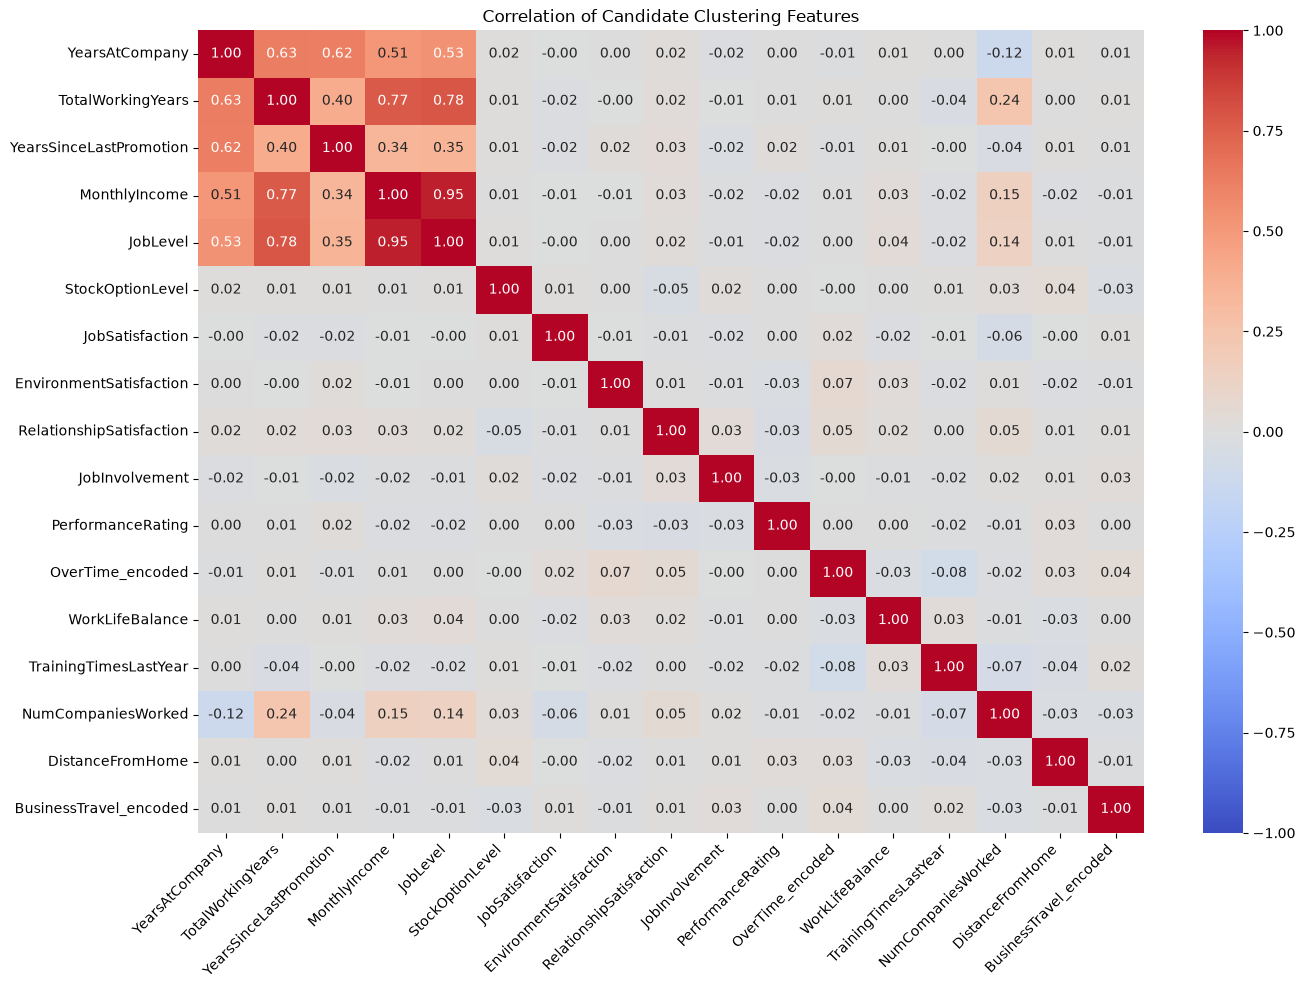

In [145]:
candidate_clustering_features = [
    "YearsAtCompany",
    "TotalWorkingYears",
    "YearsSinceLastPromotion",

    "MonthlyIncome",
    "JobLevel",
    "StockOptionLevel",

    "JobSatisfaction",
    "EnvironmentSatisfaction",
    "RelationshipSatisfaction",

    "JobInvolvement",
    "PerformanceRating",

    "OverTime_encoded",
    "WorkLifeBalance",

    "TrainingTimesLastYear",
    "NumCompaniesWorked",

    "DistanceFromHome",
    "BusinessTravel_encoded"
]

clustering_correlation = df[
    candidate_clustering_features
].corr()

clustering_correlation


plt.figure(figsize=(14, 10))

sns.heatmap(
    clustering_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)

plt.title("Correlation of Candidate Clustering Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [146]:
# Reduced clustering features.
# OverTime_encoded is removed because it completely dominated
# the previous clustering result and simply divided employees
# into overtime and non-overtime groups.

clustering_features = [
    # Career and tenure
    "YearsAtCompany",

    # Compensation
    "MonthlyIncome",

    # Satisfaction
    "JobSatisfaction",
    "EnvironmentSatisfaction",

    # Engagement
    "JobInvolvement",

    # Work-life balance
    "WorkLifeBalance",

    # Work context
    "DistanceFromHome"
]

In [147]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler

skewed_clustering_features = [
    "YearsAtCompany",
    "MonthlyIncome"
]

other_clustering_features = [
    feature
    for feature in clustering_features
    if feature not in skewed_clustering_features
]

In [148]:
clustering_skewed_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        (
            "log_transform",
            FunctionTransformer(
                np.log1p,
                feature_names_out="one-to-one"
            )
        ),
        ("scaler", StandardScaler())
    ]
)

clustering_numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

In [95]:
clustering_preprocessor = ColumnTransformer(
    transformers=[
        (
            "skewed",
            clustering_skewed_pipeline,
            skewed_clustering_features
        ),
        (
            "numeric",
            clustering_numeric_pipeline,
            other_clustering_features
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

In [149]:
X_clustering = df[clustering_features].copy()

X_clustering_processed = (
    clustering_preprocessor.fit_transform(X_clustering)
)

print("Original shape:", X_clustering.shape)
print("Processed shape:", X_clustering_processed.shape)

Original shape: (1470, 7)
Processed shape: (1470, 7)


In [150]:
from sklearn.cluster import (
    AgglomerativeClustering,
    KMeans
)
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score
)


clustering_results = []
clustering_labels = {}
clustering_models = {}

for number_of_clusters in range(2, 7):

    # K-Means
    kmeans = KMeans(
        n_clusters=number_of_clusters,
        random_state=42,
        n_init=10
    )

    kmeans_labels = kmeans.fit_predict(
        X_clustering_processed
    )

    clustering_models[
        ("K-Means", number_of_clusters)
    ] = kmeans

    clustering_labels[
        ("K-Means", number_of_clusters)
    ] = kmeans_labels

    clustering_results.append({
        "Model": "K-Means",
        "Clusters": number_of_clusters,
        "Silhouette": silhouette_score(
            X_clustering_processed,
            kmeans_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_clustering_processed,
            kmeans_labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_clustering_processed,
            kmeans_labels
        ),
        "Smallest_Cluster": pd.Series(
            kmeans_labels
        ).value_counts().min()
    })


    # Agglomerative clustering
    agglomerative = AgglomerativeClustering(
        n_clusters=number_of_clusters,
        linkage="ward"
    )

    agglomerative_labels = agglomerative.fit_predict(
        X_clustering_processed
    )

    clustering_models[
        ("Agglomerative", number_of_clusters)
    ] = agglomerative

    clustering_labels[
        ("Agglomerative", number_of_clusters)
    ] = agglomerative_labels

    clustering_results.append({
        "Model": "Agglomerative",
        "Clusters": number_of_clusters,
        "Silhouette": silhouette_score(
            X_clustering_processed,
            agglomerative_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_clustering_processed,
            agglomerative_labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_clustering_processed,
            agglomerative_labels
        ),
        "Smallest_Cluster": pd.Series(
            agglomerative_labels
        ).value_counts().min()
    })


    # Gaussian Mixture Model
    gaussian_mixture = GaussianMixture(
        n_components=number_of_clusters,
        covariance_type="full",
        n_init=5,
        random_state=42
    )

    gaussian_labels = gaussian_mixture.fit_predict(
        X_clustering_processed
    )

    clustering_models[
        ("Gaussian Mixture", number_of_clusters)
    ] = gaussian_mixture

    clustering_labels[
        ("Gaussian Mixture", number_of_clusters)
    ] = gaussian_labels

    clustering_results.append({
        "Model": "Gaussian Mixture",
        "Clusters": number_of_clusters,
        "Silhouette": silhouette_score(
            X_clustering_processed,
            gaussian_labels
        ),
        "Calinski_Harabasz": calinski_harabasz_score(
            X_clustering_processed,
            gaussian_labels
        ),
        "Davies_Bouldin": davies_bouldin_score(
            X_clustering_processed,
            gaussian_labels
        ),
        "Smallest_Cluster": pd.Series(
            gaussian_labels
        ).value_counts().min()
    })


In [151]:
clustering_results_df = pd.DataFrame(
    clustering_results
).sort_values(
    by="Silhouette",
    ascending=False
)

clustering_results_df.round(4)

,Model,Clusters,Silhouette,Calinski_Harabasz,Davies_Bouldin,Smallest_Cluster
3,K-Means,3,0.1371,212.8710,2.0788,327
6,K-Means,4,0.1306,195.7085,1.9704,295
0,K-Means,2,0.1300,233.8064,2.4237,727
9,K-Means,5,0.1281,182.1492,1.8228,234
12,K-Means,6,0.1244,170.5443,1.7660,183
2,Gaussian Mixture,2,0.1064,149.2108,2.9505,544
8,Gaussian Mixture,4,0.1010,165.1822,2.1166,272
1,Agglomerative,2,0.0805,125.4679,2.8487,388
13,Agglomerative,6,0.0778,119.2888,2.2136,143
4,Agglomerative,3,0.0778,124.7006,2.6891,231


In [152]:
best_result = clustering_results_df.iloc[0]

best_model_name = best_result["Model"]
best_number_of_clusters = int(
    best_result["Clusters"]
)

best_labels = clustering_labels[
    (
        best_model_name,
        best_number_of_clusters
    )
]

print("Best model:", best_model_name)
print("Number of clusters:", best_number_of_clusters)
print(
    "Silhouette score:",
    round(best_result["Silhouette"], 4)
)
print(
    "Davies-Bouldin score:",
    round(best_result["Davies_Bouldin"], 4)
)

Best model: K-Means
Number of clusters: 3
Silhouette score: 0.1371
Davies-Bouldin score: 2.0788


Cluster
0    1054
1     416
Name: count, dtype: int64

In [153]:
cluster_percentages = (
    df_clustered["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

cluster_percentages

Cluster
0    22.2
1    39.7
2    38.0
Name: proportion, dtype: float64

In [154]:
df_clustered = df.copy()
df_clustered["Cluster"] = best_labels

In [155]:
cluster_sizes = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
)

cluster_percentages = (
    df_clustered["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(1)
)

print("Cluster sizes:")
print(cluster_sizes)

print("\nCluster percentages:")
print(cluster_percentages)

Cluster sizes:
Cluster
0    327
1    584
2    559
Name: count, dtype: int64

Cluster percentages:
Cluster
0    22.2
1    39.7
2    38.0
Name: proportion, dtype: float64


In [156]:
cluster_profile = (
    df_clustered
    .groupby("Cluster")[
        clustering_features
        + [
            "OverTime_encoded",
            "Attrition_encoded"
        ]
    ]
    .mean()
    .round(2)
)

cluster_profile["Employee_Count"] = (
    df_clustered
    .groupby("Cluster")
    .size()
)

cluster_profile = cluster_profile.rename(
    columns={
        "OverTime_encoded": "OverTime_Rate",
        "Attrition_encoded": "Attrition_Rate"
    }
)

cluster_profile["OverTime_Rate"] = (
    cluster_profile["OverTime_Rate"] * 100
).round(1)

cluster_profile["Attrition_Rate"] = (
    cluster_profile["Attrition_Rate"] * 100
).round(1)

cluster_profile

,YearsAtCompany,MonthlyIncome,JobSatisfaction,EnvironmentSatisfaction,JobInvolvement,WorkLifeBalance,DistanceFromHome,OverTime_Rate,Attrition_Rate,Employee_Count
Cluster,,,,,,,,,,
0,6.88,6112.52,2.75,2.69,2.72,2.72,22.05,30.0,20.0,327
1,3.36,3433.74,2.53,2.70,2.81,2.73,5.58,28.0,22.0,584
2,10.89,9937.77,2.92,2.77,2.65,2.82,5.45,28.0,8.0,559


Cluster interpretation
Cluster 0 — Commute-burdened mid-career employees
Employees:             327
Years at company:      6.88
Monthly income:        6,112.52
Distance from home:   22.05
Overtime rate:         30%
Attrition rate:        20%

This cluster’s defining characteristic is the very high DistanceFromHome. Their average commute distance is much higher than the overall workforce average of approximately 9.19.

They have moderate tenure and income but a higher-than-average attrition rate. Long commuting distance may be contributing to retention risk.

Cluster 1 — Flight-risk newcomers
Employees:             584
Years at company:      3.36
Monthly income:        3,433.74
Job satisfaction:      2.53
Overtime rate:         28%
Attrition rate:        22%

This group has:

The shortest tenure.
The lowest income.
The lowest job satisfaction.
The highest attrition rate.

They are the clearest flight-risk persona. Interestingly, their job involvement is relatively high at 2.81, suggesting they may be engaged in their work but dissatisfied with compensation, progression, or their overall job experience.

Cluster 2 — Stable high-earning veterans
Employees:             559
Years at company:     10.89
Monthly income:        9,937.77
Job satisfaction:      2.92
Work-life balance:     2.82
Attrition rate:         8%

This is the most stable employee group. They have:

The longest tenure.
The highest income.
The highest job satisfaction.
The strongest work-life balance.
The lowest attrition rate.

This cluster represents established employees who appear comparatively satisfied and unlikely to leave.

In [157]:
persona_mapping = {
    0: "Commute-burdened mid-career employees",
    1: "Flight-risk newcomers",
    2: "Stable high-earning veterans"
}

df_clustered["Persona"] = (
    df_clustered["Cluster"].map(persona_mapping)
)

In [158]:
df_clustered[
    [
        "Cluster",
        "Persona",
        "YearsAtCompany",
        "MonthlyIncome",
        "JobSatisfaction",
        "DistanceFromHome",
        "OverTime_encoded",
        "Attrition_encoded"
    ]
].head()

,Cluster,Persona,YearsAtCompany,MonthlyIncome,JobSatisfaction,DistanceFromHome,OverTime_encoded,Attrition_encoded
0,2,Stable high-earning veterans,6,5993,4,1,1,1
1,2,Stable high-earning veterans,10,5130,2,8,0,0
2,1,Flight-risk newcomers,0,2090,3,2,1,1
3,1,Flight-risk newcomers,8,2909,3,3,1,0
4,1,Flight-risk newcomers,2,3468,2,2,0,0


K-Means identified three exploratory employee personas. Flight-risk newcomers had the shortest tenure, lowest income, lowest job satisfaction and highest attrition rate of 22%. Commute-burdened mid-career employees had exceptionally long commuting distances and an attrition rate of 20%. Stable high-earning veterans had the longest tenure, highest income and satisfaction levels, and the lowest attrition rate of 8%. Although the silhouette score indicated overlapping clusters, the personas revealed meaningful and actionable workforce differences.